<a href="https://colab.research.google.com/github/Slautin/camm_hackathon/blob/k4my4r/docs/day_5_21072025/2025_KMC_sputtering_CAMM_hackaton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kinetic Monte Carlo Film Growth: A Hackathon Toy Model



## Kinetic Monte Carlo Model of Film Growth

We represent the film on a **hexagonal close-packed (HCP)** lattice, implemented either in **2D** (coordination number 6) or **3D** (coordination number 12). Film growth is simulated using a simplified **Kinetic Monte Carlo (KMC)** scheme.

We approximate deposition using a **constant flux** of particles rather than discrete pulses. The ablated species are modeled as *pseudo-atoms* that arrive and occupy available surface lattice sites.

---

### Particle Dynamics

Each incoming particle undergoes a recursive sequence:

1. It attempts to attach by forming a bond with at least one neighboring lattice site.  
2. If no bond is formed, it hops to a nearby surface site.  
3. The cycle repeats until the particle eventually attaches.

We assume that each particle makes **only a single attempt** to form a bond with each neighbor.

---

## Bond-Formation Probability

The probability of forming a bond between atoms of types $X$ and $Y$ is:

$$
p_{X,Y} = \exp\!\left( -\frac{E^{\mathrm{act}}_{X,Y}}{k_B T} \right)
\tag{1}
$$

where $E^{\mathrm{act}}_{X,Y}$ is the activation energy (barrier) for the bond formation.

---

## Particle Attachment Probability

Let $n_A$ be the number of neighboring atoms of type $A$.  
The probability that a particle of type $X$ fails to form a bond with all neighbors is:

$$
P_{\mathrm{refl}} = \prod_A \left( p_{X,Y} \right)^{n_A}
\tag{2}
$$

Thus, the probability that the particle attaches is:

$$
P_{\mathrm{att}} = 1 - P_{\mathrm{refl}}
= 1 - \prod_A \left( p_{X,Y} \right)^{n_A}
\tag{3}
$$

---

## Activation Energies and Hyperparameters

Bond-formation barriers depend on atom types, e.g.:

$$
E^{\mathrm{act}}_{X,X}, \quad
E^{\mathrm{act}}_{Y,Y}, \quad
E^{\mathrm{act}}_{X,Y}, \ldots
\tag{4}
$$

These serve as **tunable hyperparameters** of the model.

To represent **kink motion**, the activation barrier for atoms bonding within the same row is additionally reduced by a coefficient (also treated as a tunable hyperparameter).

---

## Additional Assumptions

- **First-layer attachment** (on the substrate) always occurs:

$$
P_{\mathrm{att}} = 1
\tag{5}
$$

- The **film composition** is determined solely by the **incoming flux ratios** of different particle types.



In [1]:
import torch
from torch import tensor as tt

import numpy as np
import matplotlib.pyplot as plt
from itertools import product, combinations_with_replacement

import math
from typing import Tuple, List, Union

In [2]:
#@title Methods

@torch.jit.script
def p_XY_torch(Eact_XY: Union[float, torch.Tensor], device: torch.device = torch.device("cpu"), T: float = 700.0,) -> torch.Tensor:
    """TorchScript-safe sticking probability p_{X,Y} = exp(-Eact / (kB*T))."""
    # Ensure Eact_XY is a tensor
    kB = 8.617333262e-5
    if isinstance(Eact_XY, float):
        Eact = torch.tensor(Eact_XY, dtype=torch.float32, device=device)
    else:
        Eact = Eact_XY.to(dtype=torch.float32, device=device)
    return torch.exp(-Eact / (kB * T))

def hex_lattice_torch(nx=10, ny=5, a=1.0, device="cpu"):
    """Generate 2D hexagonal lattice coordinates (torch version)."""
    dy = math.sqrt(3) / 2 * a
    coords = torch.zeros((ny, nx, 2), dtype=torch.float32, device=device)
    for j in range(ny):
        y = j * dy
        x_shift = (j % 2) * (a / 2)
        x = torch.arange(nx, dtype=torch.float32, device=device) * a + x_shift
        coords[j, :, 0] = x
        coords[j, :, 1] = y
    return coords

@torch.jit.script
def hex_neighbors_torch(
    i: int,
    j: int,
    max_bound: Tuple[int, int],
    device: torch.device
) -> torch.Tensor:
    """Return 6 nearest neighbors (TorchScript-safe)."""

    if (i % 2) == 1:  # even row
        neigh = torch.tensor(
            [
                [i - 1, j],
                [i + 1, j],
                [i, j - 1],
                [i + 1, j + 1],
                [i, j + 1],
                [i - 1, j + 1],
            ],
            dtype=torch.long,
            device=device,
        )
    else:
        neigh = torch.tensor(
            [
                [i - 1, j],
                [i + 1, j],
                [i, j - 1],
                [i + 1, j - 1],
                [i, j + 1],
                [i - 1, j - 1],
            ],
            dtype=torch.long,
            device=device,
        )

    nx = max_bound[0]
    ny = max_bound[1]

    mask = (
        (neigh[:, 0] >= 0)
        & (neigh[:, 1] >= 0)
        & (neigh[:, 0] < nx)
        & (neigh[:, 1] < ny)
    )
    neigh = neigh[mask]
    return neigh

def first_false_indices_torch(arr: torch.Tensor) -> torch.Tensor:
    """Return (i, j) for first 0 along axis 0 per column (torch version)."""
    has_false = (arr == 0).any(dim=0)
    js = torch.nonzero(has_false).squeeze(1)
    # Find first zero along each selected column
    is_ = torch.stack([torch.nonzero(arr[:, j] == 0)[0][0] for j in js])
    return torch.stack((is_, js), dim=1)

@torch.jit.script
def sputtering_torch_jit(
    nodes: torch.Tensor,
    film: torch.Tensor,
    Ea_tensor: torch.Tensor,
    t: float,
    flow: torch.Tensor,
    n_particles: int,
    device: torch.device,
    T: float,
    seed: int
) -> Tuple[torch.Tensor, List[List[int]]]:
    """TorchScript-compatible inner loop for sputtering simulation."""

    torch.manual_seed(seed)
    sputtered_particles = n_particles
    sticked_p_counter = 0
    sputtered_p_counter = 0
    log: List[List[int]] = []

    atom_count = flow.size(0)
    choices = torch.arange(1, atom_count + 1, device=device)
    p_stream = choices[torch.multinomial(flow, sputtered_particles, replacement=True)]

    for p in p_stream:
        sputtered_p_counter += 1
        surf_indexes = first_false_indices_torch(film)
        if surf_indexes.numel() == 0:
            raise ValueError("Overfloated!")

        idx = torch.randint(len(surf_indexes), (1,), device=device)
        loc = surf_indexes[idx].squeeze(0)

        if loc[0] == 0:
            film[loc[0], loc[1]] = p
            sticked_p_counter += 1
        else:
            res = 0
            while res == 0:
                nx, ny = int(nodes.shape[0]), int(nodes.shape[1])
                neigh = hex_neighbors_torch(
                    int(loc[0].item()), int(loc[1].item()), (nx, ny), device
                )
                n_atoms = film[neigh[:, 0], neigh[:, 1]]
                unique, counts = torch.unique(n_atoms, return_counts=True)

                refl_prob = torch.tensor(1.0, device=device)
                for u, c in zip(unique, counts):
                    if u != 0:
                        u_idx = int(u.item()) - 1
                        p_idx = int(p.item()) - 1
                        Ea_up = Ea_tensor[u_idx, p_idx]
                        refl_prob *= (1 - p_XY_torch(Ea_up, device=device, T=T)) ** c

                res_flag = torch.rand(1, device=device) < (1 - refl_prob)
                res = int(p.item()) if res_flag else 0

                if res == 0:
                    _criteria = torch.norm(surf_indexes.float() - loc.float(), dim=1)
                    near = surf_indexes[_criteria < 3]
                    if near.numel() > 0:
                        loc = near[torch.randint(len(near), (1,), device=device)][0]

            sticked_p_counter += 1
            film[loc[0], loc[1]] = res

        log.append([int(p.item()), int(loc[0].item()), int(loc[1].item())])

        if sticked_p_counter >= sputtered_particles:
            break

    return film, log

def sputtering_torch(
    nodes,
    film=None,
    atoms=["A", "B"],
    Ea={("A", "A"): 0.1, ("A", "B"): 0.1, ("B", "B"): 0.1},
    t=1.0,
    flow=100,
    n_particles=None,
    T = 700,
    device="cpu",
    seed = None
):
    """Wrapper for the JIT-compiled sputtering core."""

    device = torch.device(str(device))

    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    if film is None:
        film = torch.zeros(nodes.shape[:-1], dtype=torch.int64, device=device)

    # Map atoms to indices
    atom_index = {a: i for i, a in enumerate(atoms)}

    # Build Ea tensor (symmetric)
    Ea_tensor = torch.zeros((len(atoms), len(atoms)), dtype=torch.float64, device=device)
    for (a1, a2), v in Ea.items():
        i, j = atom_index[a1], atom_index[a2]
        Ea_tensor[i, j] = v
        Ea_tensor[j, i] = v

    # Flow normalization
    if isinstance(flow, (int, float)):
        flow = torch.full((len(atoms),), float(flow), device=device, dtype=torch.float64)
    else:
        flow = flow.to(dtype=torch.float64, device=device)

    sputtered_particles = int(flow.sum().item() * t) if n_particles is None else n_particles

    # Call JIT-compiled function
    film_out, log = sputtering_torch_jit(nodes, film, Ea_tensor, t, flow, sputtered_particles, device, T=T, seed=seed)

    return film_out, log

def run_once(params):
    nodes, Ea, atoms, flow, t, T, seed = params
    film, log = sputtering_torch(nodes, Ea=Ea, atoms=atoms,
                                 flow=flow, t=t,
                                 device=torch.device('cpu'),
                                 T = T,
                                 seed=seed)

    sr = surface_roughness_torch(
        torch.argmin((film > 0).float(), axis=0), norm_coef=1)

    return float(sr)

def surface_roughness_torch(image_2d, norm_coef=1.0):
    """
    Compute RMS roughness of a 2D array using PyTorch.
    """
    # ensure float type
    image_2d = image_2d.to(torch.float32)

    mean_val = image_2d.mean()
    rms = torch.sqrt(torch.mean((image_2d - mean_val) ** 2))
    return rms * norm_coef

## Lattice structure

In [3]:
atoms=['A', 'B'] #atom types
nodes= hex_lattice_torch(nx=10, ny=10)

Text(0.5, 1.0, 'Lattice Sites')

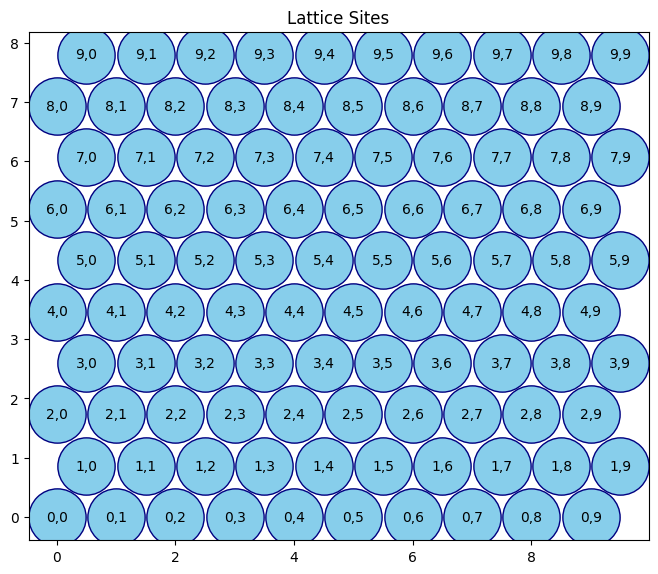

In [4]:
fig = plt.figure(figsize=(8,8))

plt.scatter(*nodes.reshape(-1, 2).T, s=1700, c='skyblue', lw=1, ec='navy')

for i in range(nodes.shape[0]):
  for j in range(nodes.shape[1]):
    plt.text(*nodes[i,j], f'{i},{j}', ha='center', va='center')


plt.gca().set_aspect('equal', adjustable='box')

plt.title('Lattice Sites')


In [5]:
#select node (lattice site)
the_node = (2,3)

#node's neighbours (neighbouring lattice sites)
neighbours = hex_neighbors_torch(the_node[0], the_node[1], max_bound=nodes.shape[:2], device='cpu')

Text(0.5, 1.0, 'Lattice Sites')

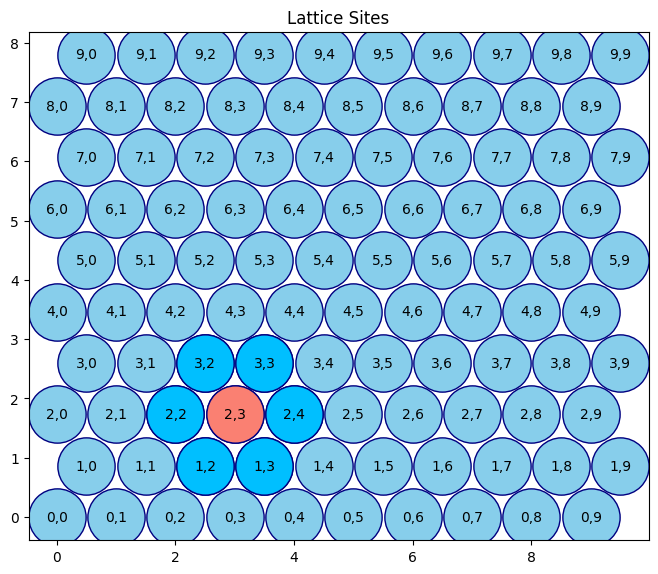

In [6]:
fig = plt.figure(figsize=(8,8))

plt.scatter(*nodes.reshape(-1, 2).T, s=1700, c='skyblue', lw=1, ec='navy', label = 'sites')
plt.scatter(*nodes[the_node], s=1700, c='salmon', lw=1, ec='navy', label='the site')
plt.scatter(*nodes[neighbours[:,0], neighbours[:,1]].T, s=1700, c='deepskyblue', lw=1, ec='navy', label='neibours')

for i in range(nodes.shape[0]):
  for j in range(nodes.shape[1]):
    plt.text(*nodes[i,j], f'{i},{j}', ha='center', va='center')


plt.gca().set_aspect('equal', adjustable='box')

plt.title('Lattice Sites')

## Sputtering

In [7]:
#@title parameters

atoms=['A', 'B'] #atom types
x = 0.2 #compositoon AxB1-x
T = 700. #temperature oC

t = 20 #"sputtering time"
sputtering_rate = 100. #sputtering rate
#total number of particle in the film: t*sputtering_rate


nodes= hex_lattice_torch(nx=100, ny=100) #lattice site

#bounds activation energies
Ea={('A','A'): 0.001,
    ('A', 'B'): 0.02,
    ('B','B'): 0.1}

flow = tt([x * sputtering_rate, (1 - x) * sputtering_rate])

In [8]:
#single film "sputtering"
film, log = sputtering_torch(nodes, Ea=Ea, atoms=atoms,
                                 flow=flow, t=t,
                                 device=torch.device('cpu'),
                                 T = T,
                                 seed=0)

#rms_roughness
sr = surface_roughness_torch(
        torch.argmin((film > 0).float(), axis=0), norm_coef=1)
print(r'Surface Roughness: {}'.format(round(float(sr),3)))

Surface Roughness: 3.937


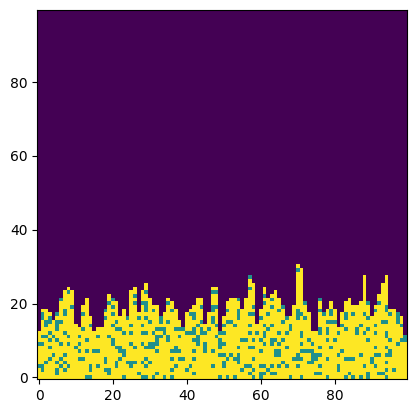

In [9]:
#film visualization
plt.imshow(film, origin='lower')

In [10]:
#particle log - [particle type, y_ind, x_ind]
print(log)

[[2, 0, 7], [2, 0, 67], [2, 0, 35], [2, 0, 19], [2, 0, 77], [2, 0, 72], [1, 0, 13], [2, 0, 42], [2, 0, 80], [2, 0, 0], [2, 0, 56], [1, 0, 78], [2, 0, 41], [2, 0, 16], [2, 1, 78], [2, 1, 7], [2, 0, 55], [2, 0, 38], [2, 0, 18], [2, 0, 96], [2, 0, 69], [2, 0, 12], [1, 0, 83], [2, 1, 12], [2, 0, 2], [2, 0, 11], [2, 1, 55], [2, 0, 88], [2, 1, 11], [2, 0, 75], [2, 0, 92], [2, 0, 46], [1, 0, 87], [1, 0, 29], [2, 1, 88], [2, 0, 44], [2, 0, 97], [2, 0, 9], [2, 0, 8], [2, 1, 97], [2, 0, 20], [1, 0, 71], [2, 1, 69], [2, 0, 6], [2, 0, 64], [2, 1, 6], [2, 0, 26], [1, 0, 68], [2, 0, 70], [2, 0, 86], [2, 1, 2], [2, 1, 77], [1, 0, 51], [2, 0, 27], [2, 0, 98], [2, 1, 96], [2, 0, 50], [2, 0, 5], [1, 2, 55], [2, 1, 68], [2, 1, 13], [1, 0, 58], [1, 0, 28], [2, 1, 38], [2, 1, 87], [1, 1, 27], [2, 0, 79], [2, 0, 74], [1, 0, 14], [2, 0, 76], [2, 1, 14], [2, 0, 21], [2, 1, 98], [2, 2, 13], [1, 0, 89], [2, 0, 91], [1, 0, 85], [1, 2, 96], [2, 1, 80], [1, 0, 36], [2, 0, 25], [2, 2, 2], [2, 0, 52], [1, 0, 31], [2

We can use multiprocessing for the simultenious films sputtering. But `film`tensor is to heavy for that.

In [11]:
from multiprocessing import cpu_count, Pool
print(cpu_count()) #for multiprocessing

8


In [12]:
#@title parameters

atoms=['A', 'B'] #atom types
x = 0.2 #compositoon AxB1-x
T = 700. #temperature oC

t = 20 #"sputtering time"
sputtering_rate = 100. #sputtering rate
#total number of particle in the film: t*sputtering_rate


nodes= hex_lattice_torch(nx=100, ny=100) #lattice site

#bounds activation energies
Ea={('A','A'): 0.001,
    ('A', 'B'): 0.02,
    ('B','B'): 0.1}

n_runs = 8 #number of "simultenious" sputtering for statistic

flow = tt([x * sputtering_rate, (1 - x) * sputtering_rate]) #particle flows
seeds = (np.arange(n_runs)+1).astype(int)**2

params = [(nodes, Ea, atoms, flow, t, T, s) for s in seeds]

with Pool(processes=n_runs) as pool:
    roughnesses = pool.map(run_once, params)
roughnesses = np.array(roughnesses)

print(f'Roughness {round(float(np.mean(roughnesses)),3)}\
 +/- {round(np.std(roughnesses),3)}')

Roughness 3.738 +/- 0.264


In [13]:
#@title grid search

x = .2 #composition AxB1-x
t = 20
T=700

#outer theory update object space
a_a = np.linspace(0.001, 0.3, 10) #depolarization coef
b_b = np.linspace(0.001, 0.3, 10) # K nearest neighbors coupling const
coord_adj = np.array(list(product(a_a, b_b)))
roughness_ar = []#np.zeros(len(coord_adj))

atoms=['A', 'B']
device = torch.device('cpu')

n_runs = 4

nodes= hex_lattice_torch(nx=100, ny=100)

seeds = (2**np.arange(n_runs)).tolist()
print('Seeds: ', seeds)


for i, ea in enumerate(coord_adj):
  print(f'------Iteration {i}----------')
  Ea={('A','A'): ea[0],
    ('A', 'B'): ea.mean(),
    ('B','B'): ea[1]}

  flow = tt([x * 100., (1 - x) * 100.])

  params = [(nodes, Ea, atoms, flow, t, T, s) for s in seeds]

  # Prepare parameters
  #params = (nodes, Ea, atoms, flow, t)

  with Pool(processes=n_runs) as pool:
      _rough = pool.map(run_once, params)

  _rough = np.array(_rough)

  roughness_ar.append(_rough)
  print(f'Roughness {round(float(np.mean(_rough)),3)} +/- {round(np.std(_rough),3)}')

roughness_ar = np.array(roughness_ar)




Seeds:  [1, 2, 4, 8]
------Iteration 0----------
Roughness 4.543 +/- 0.203
------Iteration 1----------
Roughness 4.335 +/- 0.231
------Iteration 2----------
Roughness 4.27 +/- 0.321
------Iteration 3----------
Roughness 3.844 +/- 0.144
------Iteration 4----------
Roughness 3.511 +/- 0.293
------Iteration 5----------
Roughness 3.357 +/- 0.282
------Iteration 6----------
Roughness 3.39 +/- 0.087
------Iteration 7----------
Roughness 3.606 +/- 0.205
------Iteration 8----------
Roughness 3.555 +/- 0.379
------Iteration 9----------
Roughness 3.125 +/- 0.233
------Iteration 10----------
Roughness 4.401 +/- 0.234
------Iteration 11----------
Roughness 4.208 +/- 0.251
------Iteration 12----------
Roughness 3.716 +/- 0.263
------Iteration 13----------
Roughness 3.503 +/- 0.276
------Iteration 14----------
Roughness 3.526 +/- 0.2
------Iteration 15----------
Roughness 3.5 +/- 0.428
------Iteration 16----------
Roughness 3.406 +/- 0.227
------Iteration 17----------
Roughness 3.692 +/- 0.296
-----

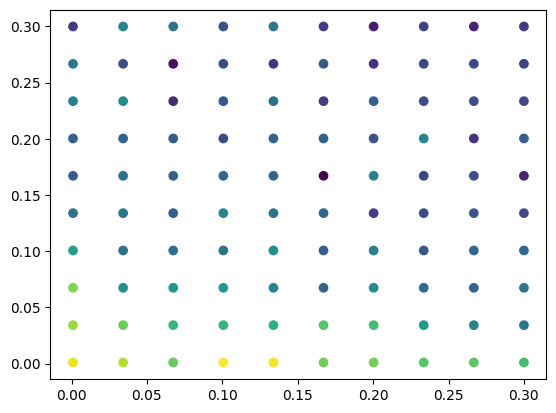

In [14]:
plt.scatter(*coord_adj.T, c=roughness_ar.mean(1))

Text(0.5, 1.0, '$E_a$ space')

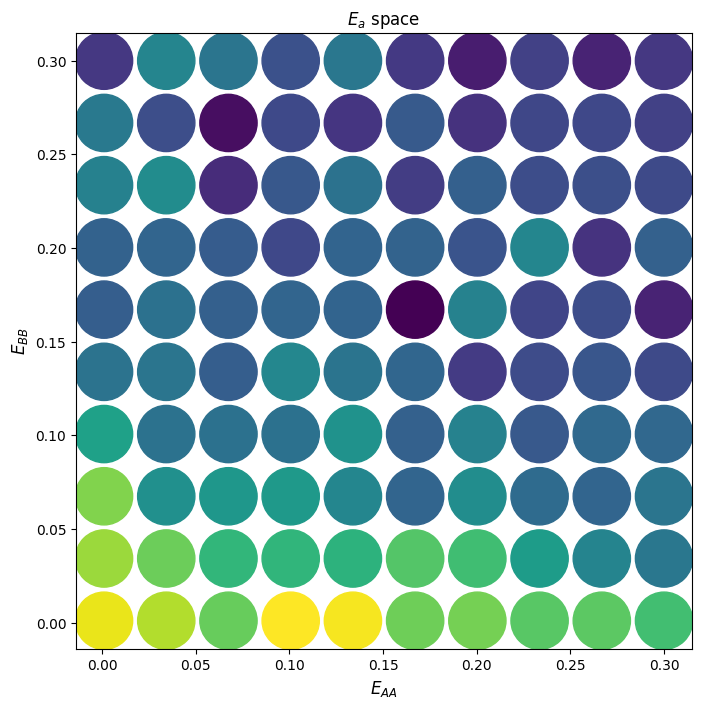

In [15]:
fig = plt.figure(figsize=(8,8))

plt.scatter(*coord_adj.T, c=roughness_ar.mean(1), s=1700)
plt.xlabel('$E_{AA}$', fontsize=12)
plt.ylabel('$E_{BB}$', fontsize=12)


plt.gca().set_aspect('equal', adjustable='box')

plt.title('$E_a$ space')